In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

plt.style.use("ggplot")

In [9]:
df = pd.read_csv("Data_Bayes.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [10]:
print("="*50)
print("Dataset Shape")
print("="*50)
print(df.shape)

print("\n")

print("="*50)
print("Column Names")
print("="*50)
print(df.columns)

print("\n")

print("="*50)
print("Dataset Info")
print("="*50)
print(df.info())

print("\n")

print("="*50)
print("Missing Values")
print("="*50)
print(df.isnull().sum())

print("\n")

print("="*50)
print("Duplicate Rows")
print("="*50)
print(df.duplicated().sum())

print("\n")

print("="*50)
print("Statistical Summary")
print("="*50)
print(df.describe())

Dataset Shape
(569, 33)


Column Names
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis

In [11]:
df.drop(columns=["id","Unnamed: 32"], inplace=True)

In [12]:
df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})

In [13]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


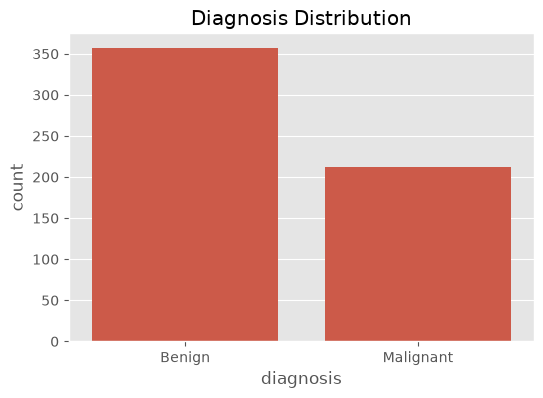

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="diagnosis"
)

plt.title("Diagnosis Distribution")
plt.xticks([0,1],["Benign","Malignant"])
plt.show()

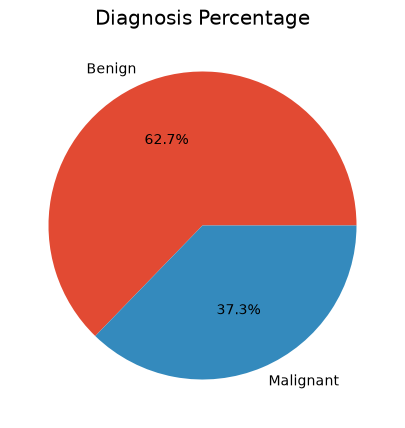

In [15]:
plt.figure(figsize=(5,5))

df["diagnosis"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Benign","Malignant"]
)

plt.title("Diagnosis Percentage")
plt.ylabel("")
plt.show()

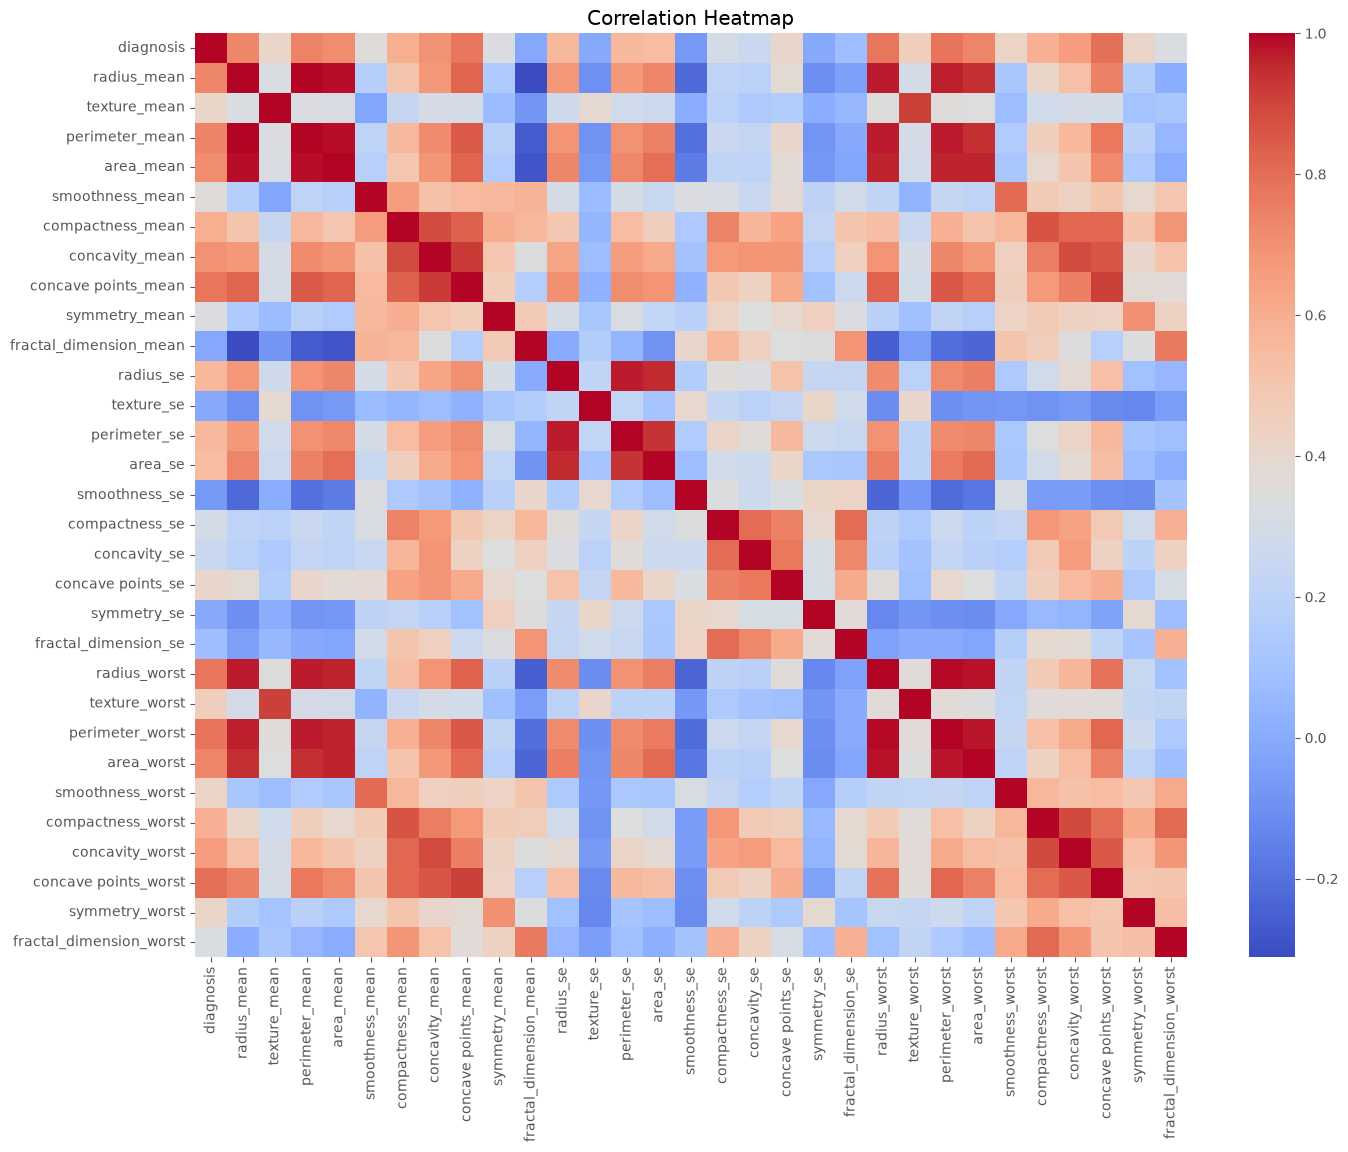

In [16]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

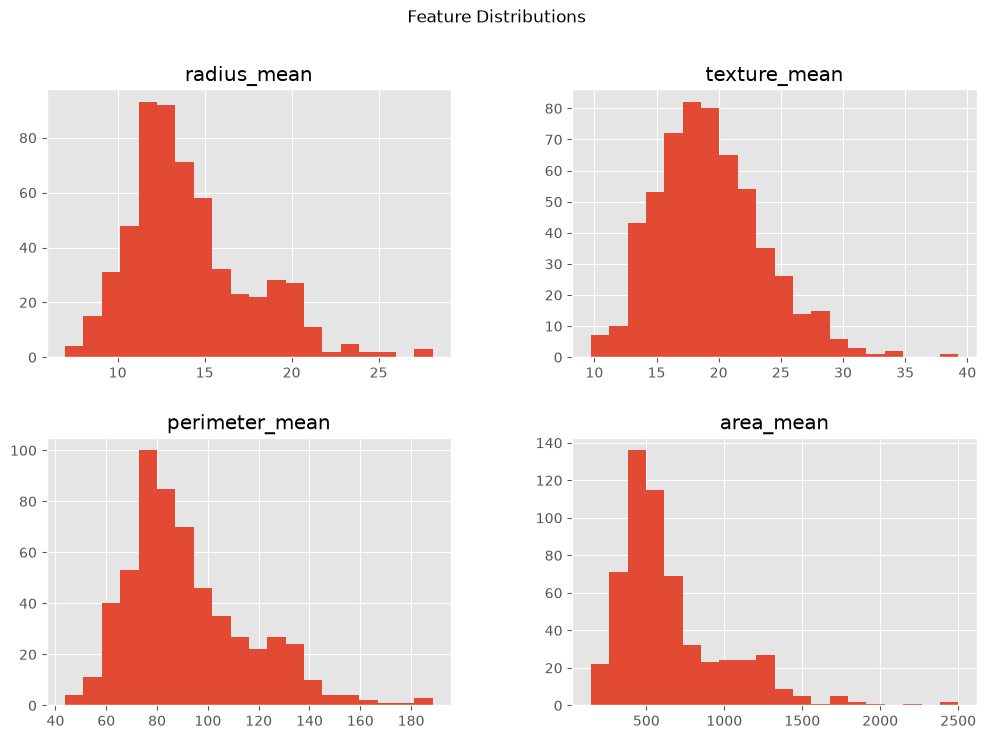

In [17]:
features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean"
]

df[features].hist(
    figsize=(12,8),
    bins=20
)

plt.suptitle("Feature Distributions")

plt.show()

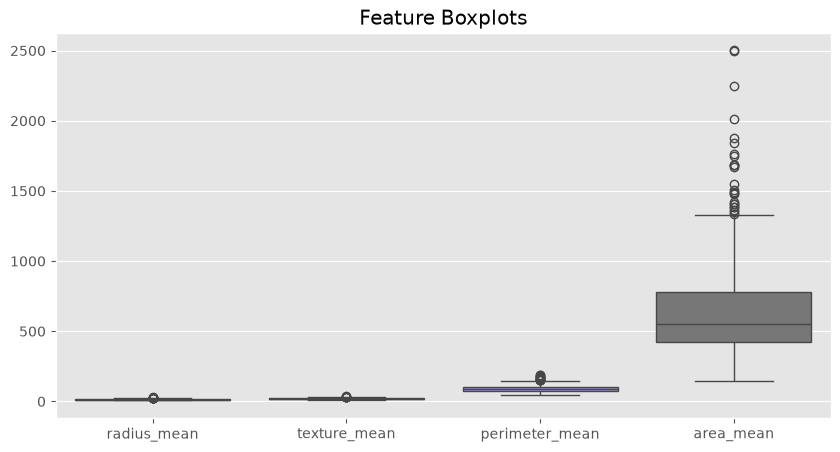

In [18]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df[features])

plt.title("Feature Boxplots")

plt.show()

In [19]:
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [21]:
model = GaussianNB()

model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[285.,170.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.63,0.37]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.0003384
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](30,)","['radius_mean','texture_mean','perimeter_mean',...,'concave points_worst', 'symmetry_worst','fractal_dimension_worst']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 30)","[[ 12.16, 18.05, 78.1 ,..., 0.07, 0.27, 0.08], [ 17.54, 21.71,115.87,..., 0.18, 0.33, 0.09]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 30)","[[ 3.17, 15.49,139.65,..., 0. , 0. , 0. ], [ 10.76, 14.79,503.93,..., 0. , 0.01, 0. ]]"


In [22]:
prediction = model.predict(X_test)

probability = model.predict_proba(X_test)[:,1]

In [23]:
accuracy = accuracy_score(y_test,prediction)

precision = precision_score(y_test,prediction)

recall = recall_score(y_test,prediction)

f1 = f1_score(y_test,prediction)

auc = roc_auc_score(y_test,probability)

In [24]:
performance = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

})

performance

,Metric,Value
0,Accuracy,0.938596
1,Precision,1.000000
2,Recall,0.833333
3,F1 Score,0.909091
4,ROC-AUC,0.993386


In [25]:
print(classification_report(
    y_test,
    prediction
))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        72
           1       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



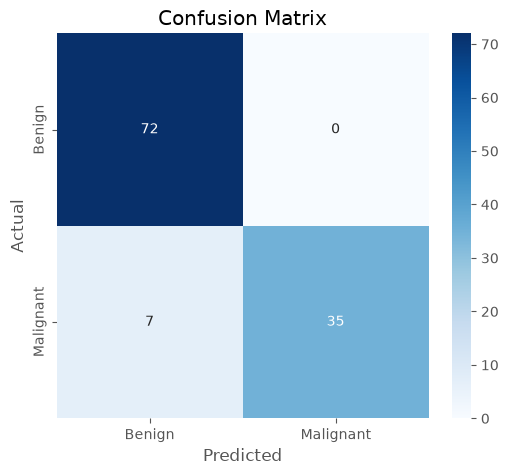

In [26]:
cm = confusion_matrix(
    y_test,
    prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign","Malignant"],
    yticklabels=["Benign","Malignant"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

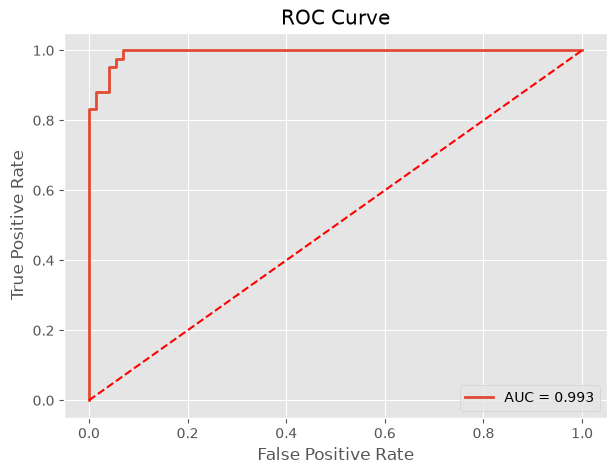

In [27]:
fpr, tpr, threshold = roc_curve(
    y_test,
    probability
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="red"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [28]:
comparison = pd.DataFrame({

    "Actual":y_test.values,

    "Predicted":prediction

})

comparison.head(15)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,0
4,0,0
5,0,0
6,1,0
7,0,0
8,0,0
9,0,0


In [29]:
print("="*60)
print("Gaussian Naive Bayes Model Summary")
print("="*60)

print(f"Accuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1 Score  : {f1:.3f}")
print(f"ROC-AUC   : {auc:.3f}")

print("="*60)

Gaussian Naive Bayes Model Summary
Accuracy  : 0.939
Precision : 1.000
Recall    : 0.833
F1 Score  : 0.909
ROC-AUC   : 0.993
